# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 6</span>


In Statistical Mechanics the one-dimensional (1D) Ising Model is exactly resoluble. The Hamiltonian for a system of N spins with nearest neighbors interaction is given by (in the following I will assume units such that $\mu_B=1$ and $k_B=1$):

$$
H = 
-J\sum_{i=1}^N s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^N (s_i + s_{i+1}) 
$$

where $\{ s_i \}_{i=1,N}$ are spin variables taking values in $\{-1;1\}$, $J>0$ (ferromagnetic model),and with the assumption $s_{N+1} = s_{1}$.

The partition function for $N$ spins, $Z$, can be exactly computed and it turns out to be:

$$
Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \lambda_1^N + \lambda_2^N
$$

where
$\lambda_{1,2} = 
e^{\beta J} 
\cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$, 
and where $\beta=\frac{1}{k_b T} = \frac{1}{T}$.
Once the partition function has been computed, the Helmholtz free energy is readly obtained as $A = -k_B T \ln Z$. All the thermodynamic quantities of interest can be deduced from $A$ or, equivalently, from $Z$:

- the **Internal Energy** per spin (with $h=0$):

$$
\frac{U(N,T)}{N} = \frac{\langle H \rangle}{N}
= \frac{1}{N} \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}
= -\frac{1}{N}\frac{\partial \ln Z}{\partial \beta}
\underset{h=0}= -J \tanh (\beta J) \Biggl( \frac{1 + \tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

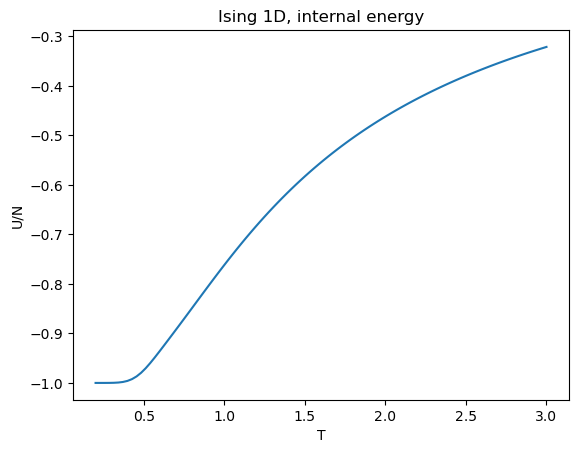

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Data Visualization package built on top of matplotlib
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )
plt.plot(T, e)
plt.title('Ising 1D, internal energy')
plt.xlabel('T')
plt.ylabel('U/N')
plt.show()

- the **Heat Capacity** (with $h=0$):

$$
C(N,T) = \frac{\partial U(N,T)}{\partial T}
= \frac{\partial \beta}{\partial T}\frac{\partial U}{\partial \beta}
= -k_B\beta^2 \frac{\partial}{\partial \beta} \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z} \right] = \\
= -k_B\beta^2 \left[ -\sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} + \sum_{\{ s_i \}} H \exp \left( -\beta H\right)\frac{\partial Z^{-1}}{\partial \beta} \right] = \\
= k_B\beta^2 \left\{ \sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} + \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}\right]\frac{1}{Z}\frac{\partial Z}{\partial \beta} \right\} =\\
= k_B\beta^2 \left\{ \sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} - \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}\right]^2 \right\} =
k_B\beta^2 \left(\langle H^2 \rangle -\langle H \rangle^2 \right)
$$

$$
\frac{C(N,T)}{N} = \frac{1}{N}\frac{\partial U(N,T)}{\partial T} =\\
\underset{h=0}= 
k_B (\beta J)^2 \left\{ 1+\tanh^N (\beta J)+(N-1)\tanh^2 (\beta J)+(N-1)\frac{\tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)}
- N \left[ \frac{\tanh (\beta J) + \tanh^{N-1} (\beta J)}{1+\tanh^N (\beta J)} \right]^2 \right\}
$$

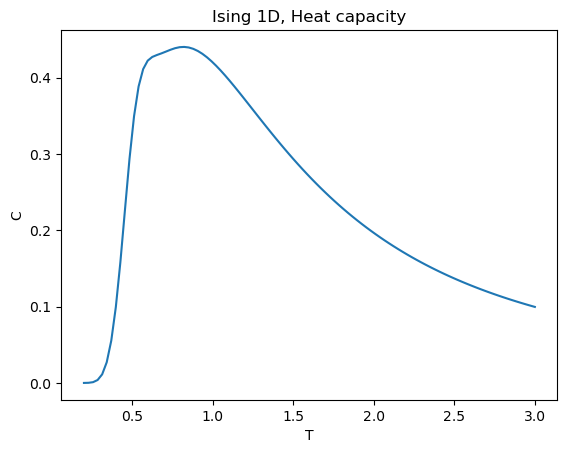

In [2]:
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
plt.plot(T, heat)
plt.title('Ising 1D, Heat capacity')
plt.xlabel('T')
plt.ylabel('C')
plt.show()

- The **magnetization** (with $h \not= 0$):

Note that with $h=0$ the magnetization $M(N,T,h=0)=\langle \sum_{i=1,N}s_i \rangle =0$ because in 1D we cannot have a (ferromagnetic) phase transition in absence of an external magnetic field.

$$
M(N,T,h) = -\frac{\partial A}{\partial h} = k_B T \frac{\partial \ln Z}{\partial h} =
\frac{1}{\beta} \frac{1}{Z}\frac{\partial}{\partial h}\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z} = \left\langle \sum_{i=1,N}s_i \right\rangle
$$

The exact formula from $M(N,T,h) = k_B T \dfrac{\partial \ln Z}{\partial h}$ is:
$$
\frac{M(N,T,h)}{N}=\frac{e^{\beta J}\; \sinh(\beta h)}{Z} \; \Bigl[\lambda_1^{N-1}\cdot \Bigl(1+\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr) + \lambda_2^{N-1}\cdot \Bigl(1-\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr)\Bigr]
$$

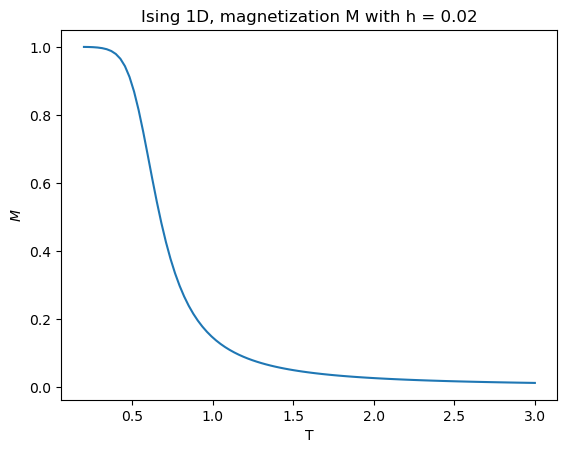

In [3]:
h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
plt.plot(T, M)
plt.title('Ising 1D, magnetization M with h = 0.02')
plt.xlabel('T')
plt.ylabel('$M$')
plt.show()

- The **magnetic susceptibility** (with $h=0$):

$$
\chi(N,T) = \frac{\partial M}{\partial h} = 
\frac{\partial}{\partial h}\sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z} =\\
= \beta\sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right]^2 \frac{\exp \left( -\beta H\right)}{Z}
-\sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z}
\frac{1}{Z}\frac{\partial Z}{\partial h} = 
\beta \left[ \left\langle \left( \sum_{i=1,N}s_i \right)^2 \right\rangle - \left\langle \sum_{i=1,N}s_i \right\rangle^2 \right] = \\
\underset{h=0}= \beta \left[ \left\langle \left( \sum_{i=1,N}s_i \right)^2 \right\rangle \right] = \beta e^{2\beta J} \Biggl( \frac{1-\tanh^N (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

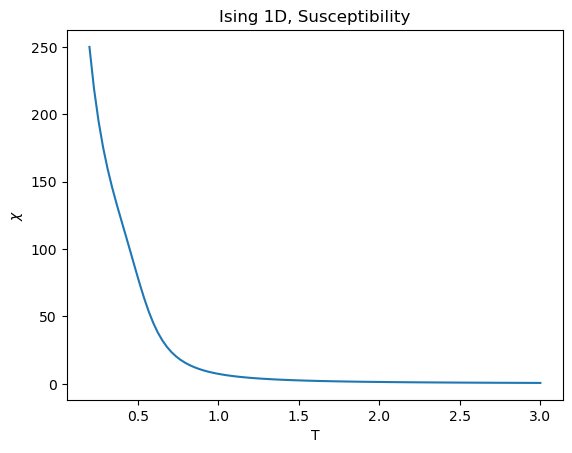

In [4]:
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)
plt.plot(T, X)
plt.title('Ising 1D, Susceptibility')
plt.xlabel('T')
plt.ylabel(r'$\chi$')
plt.show()

### Exercise 06.1

Complete the C++ code to simulate 1D Ising model (It is available on the Ariel web site of this Laboratory) with 
- the Metropolis sampling algorithm and
- the Gibbs sampling algorithm

to sample the Boltzmann's weight $p(\{ s_i \}) = \exp(-\beta H)/Z$,
adding also the possibility to restart from a previous spin configuration.

The code already computes the internal energy: $U(N,T) = \langle H \rangle$. Add the calculation of $C(N,T)$, $\chi(N,T)$, $M(N,T,h)$ and compute:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

as a function of $T$ in the range $\left[0.5;2.0\right]$ for a system of $N=50$ spins with $J=1$.

As usual, use data blocking and give an estimate of the statistical uncertainties.

- <span style="color:red">Show pictures of your estimations of $U(N,T)$, $C(N,T)$, $\chi(N,T)$, $M(N,T,h=0.02)$ and their uncertainties</span> obtained with a large number of *MC steps* (e.g. $M\ge 10^5$) compared with the exact curves. In the same picture show your results obtained with both sampling methods, Metropolis and Gibbs.

A Monte Carlo step will consist in trying to flip one time all the spins of the system. Do not forget to equilibrate your simulations and to use blocking average with blocks large enough.

# The Ising Model
-------
The Ising model is a mathematical tool used to describe a system of spins, from which one can compute its thermodynamic properties such as internal energy, heat capacity, magnetization, and susceptibility. A key feature of the Ising model is the assumption that the spin of each particle interacts only with its immediate neighbors.

## The 1-Dimensional Ising Model

We will consider the simple case of the one-dimensional Ising model, which can be thought of as a long chain of spins. This system is exactly resoluble, meaning in particular that we know both the Hamiltonian:

$$
H = 
-J\sum_{i=1}^N s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^N (s_i + s_{i+1}) 
$$

and the partition function:

$$
Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \lambda_1^N + \lambda_2^N
$$

We can then use these two epxressions to sample from the Boltzmann probability distribution function using either the Metropolis algorithm or the Gibbs algorithm:

$$
P(S) = \frac{\exp(-\beta H(S))}{Z}
$$

where:

- $H(S) = -J \sum_{i=1}^{N} S_i S_{i+1} - h \sum_{i=1}^{N} S_i$

and:

- $Z = \sum_{S} \exp(-\beta H(S))$

# Sampling Algorithms
--------

Let us recall what the Metropolis algorithm is about and introduce the Gibbs algorithm:

### The Metropolis Algorithm:

The Metropolis Algorithm is a Markov Chain Monte Carlo (MCMC) method used to sample from a probability distribution $f(x)$ from which it it difficult to sample from directly.

<u>Steps of the algorithm</u>:

1. <b>Initialization</b>: start at an initial point $x_0$ belonging to the domain of $f(x)$.
2. <b>Proposal Step</b>: draw $x$ sampled from the proposal distribution $p(x'|x)$ (easy to sample from, e.g. a Gaussian).
3. Compute the acceptance probability:
   $$
   \alpha = \min\!\Bigg(1,\ \frac{f(x')\, p(x_t \mid x')}{f(x_t)\, p(x' \mid x_t)}\Bigg)
   $$
   
   If $p(x'∣x_t)=p(x_t∣x')$ (symmetric proposal), this simplifies to:

   $$
   \alpha = \min\!\Bigg(1,\ \frac{f(x')}{f(x_t)}\Bigg)
   $$
   
5. <b>Accept or reject proposal</b>:
   
   - Draw $u$ from a uniform distribution $U(0,1)$
   - If $u \leq \alpha $, accept the cadidate:
     
     $$ x_{t+1} = x' $$
     
    - Else, reject and keep the current state:

      $$ x_{t+1} = x_t $$
      
7. Repeat for many iterations to build a chain ${x_0, x_1, ... , x_n}$


<u>Note</u>: Why using a Markov process?

The main advantage on using a Markov chain to move from a start value to the next trial value is that if we happen to "land" on a zone of high p.d.f. we get more chances to stay there and sample more values in that zone instead of just directly moving away randomly.

<u>Disadvantages</u>:

- The fact that the steps depend on a Markov chain also makes them strongly correlated.
- The Metropolis algorithm only works asymptotically

<u>Avoiding the Disadvantages</u>:

- Equilibration
- Sparse Averaging
- Data Blocking

# Simulating the Ising Model using the Metropolis Algorithm
----------
- The usage of periodic boundary conditions ensures that all spins have the same number of neighbours and local geometry.
-  Next we need to decide at what temperature we want to perform our simulation, and we need to choose some starting value for each of the spins: the initial state of the system, say $\mu$.
-  The two most commonly used initial states are the zero-temperature state and the infinite temperature state.

## Algorithm:

1) Choosing a spin
2) Calculating the energy change we would get if we flipped it
3) Deciding whether to flip it
4) Repeat

## Measuring Observables (Magnetization, Internal Energy, etc.)

1)  First we have to run our simulation for a suitably long period of Monte Carlo time until it has come to equilibrium at the temperature we are interested in.
2)  Then we have to measure the quantity, $G(\mu)$, we are interested in over
another suitably long period of MC-time and average it.


<u>Note</u>:
“Equilibrium” means that the average probability of finding our system in any particular state $\mu$ is proportional to the Boltzmann weight $p(\mu)$ of that state, i.e., we are correctly sampling $G(\mu)$.

# MC Ising 1D program workflow #
------------

### Simulation Workflow ###

1) Read input parameters

2) Initialize random generator and spins

3) Equilibrate

    - The program performs $N_{equi}$ "dry steps" to equilibrate. In fact, the initial random configuration of the system in the Monte Carlo simulation does not necessarily represent the physical configuration corresponding to a target temperature.

4) For each temperature:

    - For each block:

        - For each step:

            - Perform Monte Carlo move

            - Measure observables

        - Compute block averages

    - Output averages and error estimates

5) Save final configuration for possible restart.

# Solution to Ex. 6.1 #
------------

- <span style="color:red">Show pictures of your estimations of $U(N,T)$, $C(N,T)$, $\chi(N,T)$, $M(N,T,h=0.02)$ and their uncertainties</span> obtained with a large number of *MC steps* (e.g. $M\ge 10^5$) compared with the exact curves. In the same picture show your results obtained with both sampling methods, Metropolis and Gibbs.

A Monte Carlo step will consist in trying to flip one time all the spins of the system. Do not forget to equilibrate your simulations and to use blocking average with blocks large enough.

## Internal Energy $U$ ##

### Monte Carlo estimation idea ###

The mean internal energy $\langle U \rangle$ is the thermal average of $E$ over all possible configurations:

$$
\langle U \rangle = \sum_{\{s_i\}} E(\{s\}) P(\{s\})
$$

where: $P(\{s\}) \propto e^{-\beta H(\{s\})}$

However, since the number $2^N$ of configurations $\{s\}$ grows exponentially with the number of spins we can't directly compute them analytically. Instead we can **sample** the configurations according to their Boltzmann probability $P(\{s\})$ via the Metropolis algorithm or the Gibbs algorithm.

So we can estimate the average internal energy by sampling:

$$
\langle U \rangle \approx \frac{1}{M} \sum_{k=1}^{M} E_k
$$

where $E_k$ is the energy of the system at the $k$-th Monte Carlo step after equilibration, and M is the total number of sampled configurations.

### Inputs ###

- The system's initial configuration is prepared via the function ```void random_initial_system_config(string initial_condition, string filename)``` and saved into the file ```filename= config.0```.<br/><br/>
- An initial condition ```initial_condition``` is passed into ```Input(...)``` and then to the function ```random_initial_system_config(...)```. In the program, we set two values to ```initial_condition```:
    - ```initial_condition = "T=0" ``` <br/>
      This initial configuration corresponds to the ground state: all the spins have value $s=+1$
    - ```initial_condition = "T=inf " ``` <br/>
      Here the spins' orientations are completely random, with probabiliy $1/2$ of being $±1$<br/><br/>
- Finally, we can specify whether to use the Metropolis or the Gibbs sampling algorithms by respectively passing to ```Input(...)``` either ```metro=1``` or ```metro=0```  
### System Equilibration ###

- We then equilibrate the system with ```N_{equi}``` "dry steps" via the function ```void Equilibrate_system(int equi_steps)``` in order to make the initial configuration match with a target temperature. The equilibrated configuration is saved in ```config.final``` and serves as a starting point to the sampling algorithms.

## Step 1: Equilibrate the System ##
--------
Equilibrate the system and checking that is converges to pre-set value.

## Step 2: Compute the observables values at each increment of temperature ##
-----------
Compute the observables values [U, C, M, Chi] at each increment of temperature between 0.5 and 2.0. Then fit the results with the analytical curves.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid", context="talk")

def load_observable(prefix, suffix):
    """Helper: loads block, mean, error columns from a file."""
    path =  prefix + suffix
    if not os.path.exists(path):
        return None
    data = np.loadtxt(path)
    if data.ndim == 1:  # handle single-line files
        data = np.expand_dims(data, axis=0)
    df = pd.DataFrame({
        "Block": data[:, 0],
        "Estimate": data[:, 2],
        "Error": data[:, 3]
    })
    return df

def compare_algorithms_across_temps(base_dir, temps, algorithms, observable=".ene.0", obs_label="Energy per spin"):
    """
    Plot comparison between algorithms (e.g. Metropolis vs Gibbs)
    for multiple temperatures in a grid layout.

    Args:
        base_dir (str): Directory containing output files.
        temps (list): List of temperature values (e.g. [0.5, 1.0, 1.5, 2.0]).
        algorithms (list): List of algorithms (e.g. ["Metro", "Gibbs"]).
        observable (str): File suffix, e.g. ".ene.0", ".heat.0", ".mag.0", ".chi.0".
        obs_label (str): Label for the y-axis and title.
    """
    ncols = 2
    nrows = int(np.ceil(len(temps) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=False)
    axes = axes.flatten()

    palette = sns.color_palette("Set2", n_colors=len(algorithms))

    for i, T in enumerate(temps):
        ax = axes[i]
        for j, algo in enumerate(algorithms):
            prefix = f"{base_dir}/output_T{T}_{algo}"
            df = load_observable(prefix, observable)
            if df is None:
                print(f"Missing file: {prefix + observable}")
                continue

            sns.lineplot(
                ax=ax, data=df, x="Block", y="Estimate",
                label=algo, color=palette[j], linewidth=2.2
            )
            ax.errorbar(
                df["Block"], df["Estimate"], yerr=df["Error"],
                fmt="none", ecolor=palette[j], capsize=0, alpha=0.7
            )

        ax.set_title(f"T = {T}", fontsize=16)
        ax.set_xlabel("Block number")
        ax.set_ylabel(obs_label)
        ax.legend()

    # Clean up unused axes (if temps not multiple of ncols)
    for k in range(len(temps), len(axes)):
        fig.delaxes(axes[k])

    fig.suptitle(f"{obs_label} comparison: Metropolis vs Gibbs", fontsize=18, weight="bold", y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    sns.despine()
    plt.show()

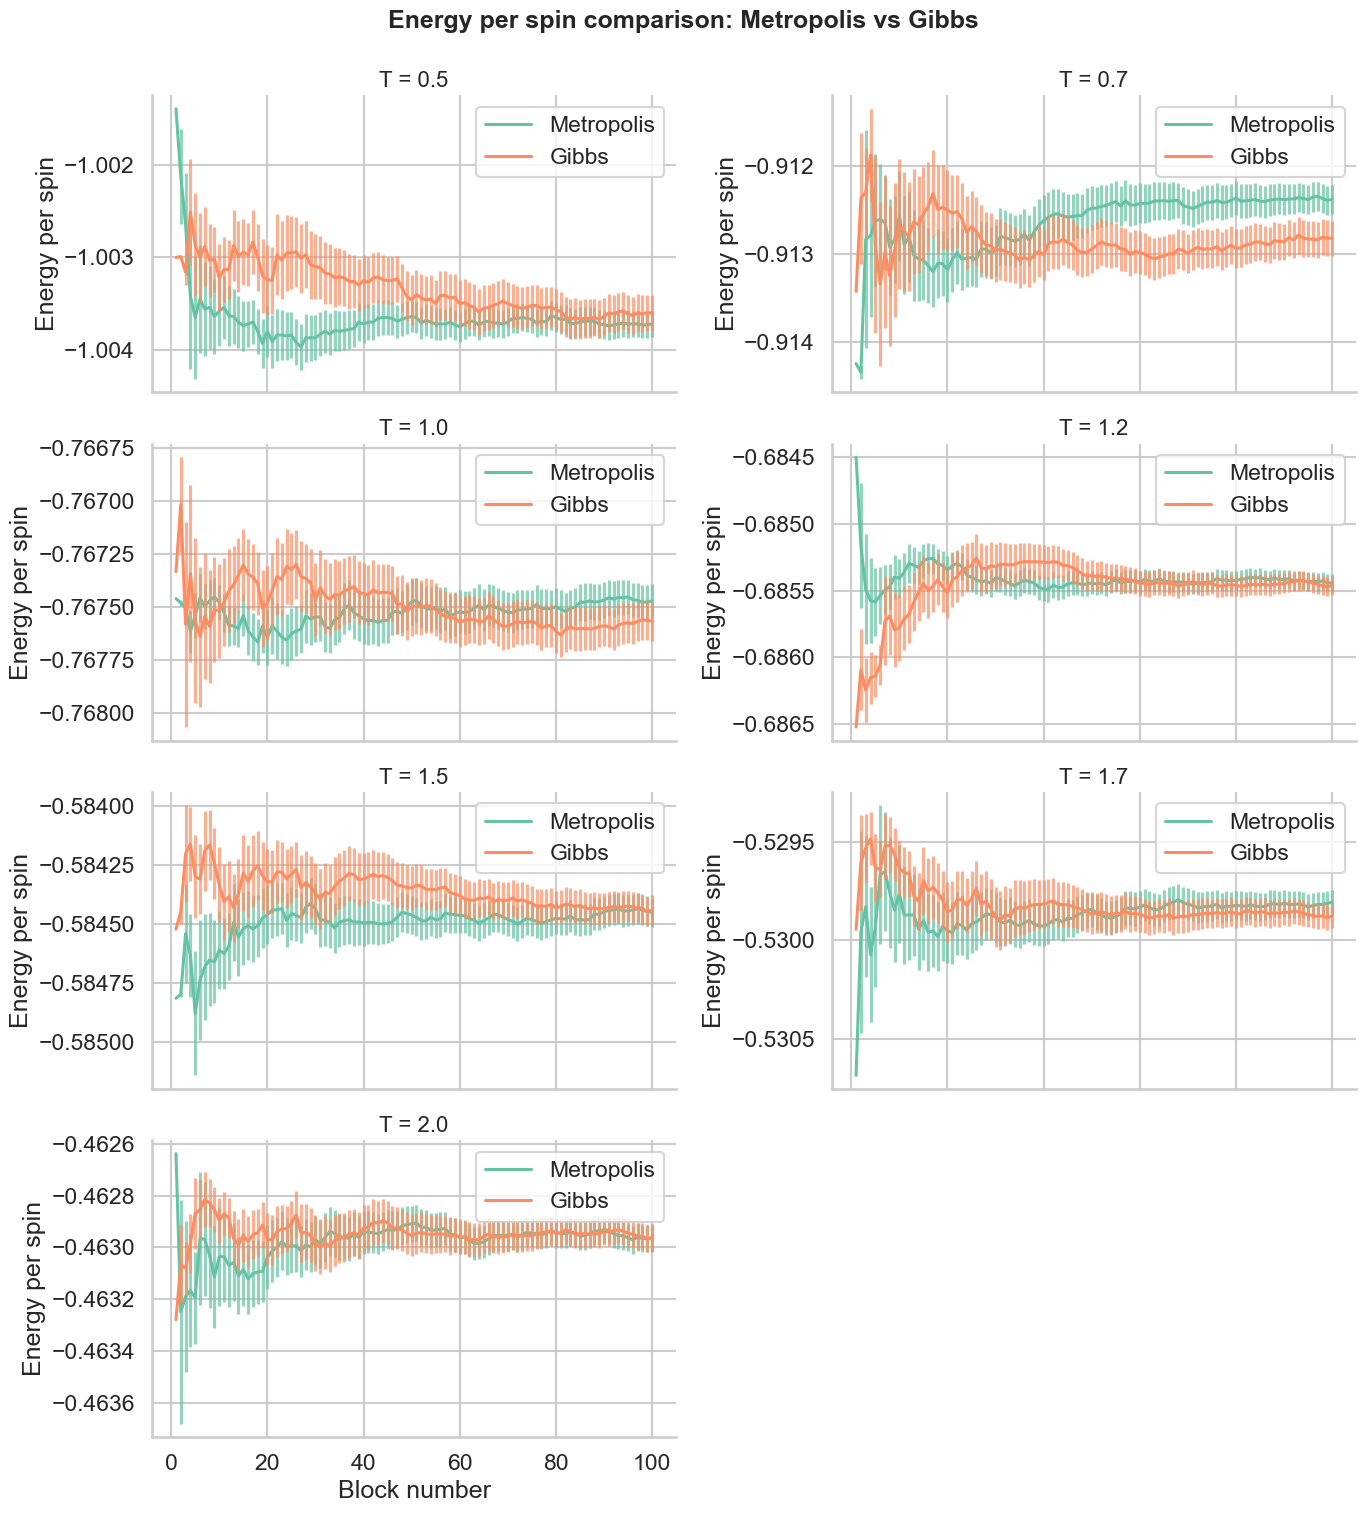

In [6]:
# Directory where files like output_T2_Metro.ene.0 are stored
base_dir = "./ISING_1D/Output_data"

# Temperatures to compare
temps = [0.5, 0.7, 1.0, 1.2, 1.5, 1.7, 2.0]

# Algorithms
algorithms = ["Metropolis", "Gibbs"]

# Energy comparison
compare_algorithms_across_temps(base_dir, temps, algorithms, observable=".ene.0", obs_label="Energy per spin")

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid", context="talk")

def analytical_heat_capacity(T_values, J=1.0, N=50):
    beta = 1.0 / np.array(T_values)
    th = np.tanh(beta * J)
    ch = np.cosh(beta * J)
    thN = np.tanh(beta * J) ** N
    Ns = N
    heat = ((beta * J) ** 2) * (
        ((1 + thN + (Ns - 1) * (th ** 2 + (ch ** 2) * thN)) / (1 + thN))
        - Ns * ((th + ch * thN) / (1 + thN)) ** 2
    )
    return heat

def analytical_magnetization(T_values, J=1.0, N=50):

    h = 0.02
    T_values = np.array(T_values, dtype=float)
    b = 1.0 / T_values  # beta for each temperature
    M = np.zeros_like(T_values)

    # Vectorized computation
    for i, beta in enumerate(b):
        exp2bJ = np.exp(2 * beta * J)
        cosh_bh = np.cosh(beta * h)
        sqrt_term = np.sqrt(exp2bJ * cosh_bh**2 - 2 * np.sinh(2 * beta * J))
        
        l1 = np.exp(beta * J) * cosh_bh + sqrt_term
        l2 = np.exp(beta * J) * cosh_bh - sqrt_term
        Z = l1**N + l2**N
        
        prefactor = np.exp(beta * J) * np.sinh(beta * h)
        term1 = l1**(N-1) * (1 + np.exp(beta * J) * cosh_bh / sqrt_term)
        term2 = l2**(N-1) * (1 - np.exp(beta * J) * cosh_bh / sqrt_term)
        M[i] = prefactor * (term1 + term2) / Z

    return M


def analytical_susceptibility(T_values, J=1.0, N=50):
    th = np.tanh(J/T_values)
    thN= th**N
    beta = 1.0 / T_values  # beta for each temperature

    X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)
    return X

# Dictionary of available analytical models
ANALYTICAL_MODELS = {
    ".heat.0": analytical_heat_capacity,
    ".mag.0": analytical_magnetization,
    ".chi.0": analytical_susceptibility
}


def collect_observable_vs_temp(base_dir, temps, algorithm, observable):
    records = []
    for T in temps:
        if abs(T) < 1e-8:
            continue

        prefix = f"{base_dir}/output_T{T}_{algorithm}"
        path = prefix + observable

        if not os.path.exists(path):
            print(f" Missing file: {path}")
            continue

        try:
            data = np.loadtxt(path)
        except Exception as e:
            print(f"Could not read {path}: {e}")
            continue

        if data.ndim == 1:
            data = np.expand_dims(data, axis=0)

        final_row = data[-1]
        mean_value = final_row[2]
        error_value = final_row[3]

        if np.isnan(mean_value) or np.isnan(error_value):
            print(f"Skipping T={T} due to NaNs.")
            continue

        records.append({
            "Temperature": T,
            "Estimate": mean_value,
            "Error": error_value
        })

    if not records:
        return None

    df = pd.DataFrame(records).sort_values("Temperature").reset_index(drop=True)
    return df

def plot_observable_vs_temp(base_dir, temps, algorithms, observable, obs_label, J=1.0, N=50):
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("Set2", n_colors=len(algorithms))

    # Plot simulation data (points + error bars)
    for i, algo in enumerate(algorithms):
        df = collect_observable_vs_temp(base_dir, temps, algo, observable)
        if df is None or df.empty:
            print(f"No valid data for {algo} in {observable}")
            continue

        plt.errorbar(
            df["Temperature"], df["Estimate"], yerr=df["Error"],
            fmt="o", markersize=6, capsize=3, elinewidth=1.5,
            label=f"{algo} simulation", color=palette[i], alpha=0.9
        )

    # If an analytical model exists for this observable, plot it
    if observable in ANALYTICAL_MODELS:
        func = ANALYTICAL_MODELS[observable]
        T_smooth = np.linspace(min([t for t in temps if t > 0.0]), max(temps), 200)
        analytic_vals = func(T_smooth, J=J, N=N)
        plt.plot(T_smooth, analytic_vals, 'k--', linewidth=2.0, label="Analytical model")

    plt.title(f"{obs_label} vs Temperature", fontsize=18, weight="bold")
    plt.xlabel("Temperature (T)")
    plt.ylabel(obs_label)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Master routine: plot all observables except energy
# ------------------------------------------------------------
def plot_all_observables_vs_temp(base_dir, temps, algorithms, J=1.0, N=50):
    observables = {
        ".heat.0": "Heat Capacity",
        ".mag.0": "Magnetization",
        ".chi.0": "Magnetic Susceptibility"
    }

    for suffix, label in observables.items():
        print(f"\nPlotting {label} across temperatures...")
        plot_observable_vs_temp(
            base_dir, temps, algorithms, observable=suffix, obs_label=label, J=J, N=N
        )



Plotting Heat Capacity across temperatures...
Could not read ./ISING_1D/Output_data/output_T0.2_Metropolis.heat.0: could not convert string '20-2.27374e-13-2.27374e-13' to float64 at row 0, column 1.
Could not read ./ISING_1D/Output_data/output_T0.2_Gibbs.heat.0: could not convert string '20-2.27374e-13-2.27374e-13' to float64 at row 0, column 1.


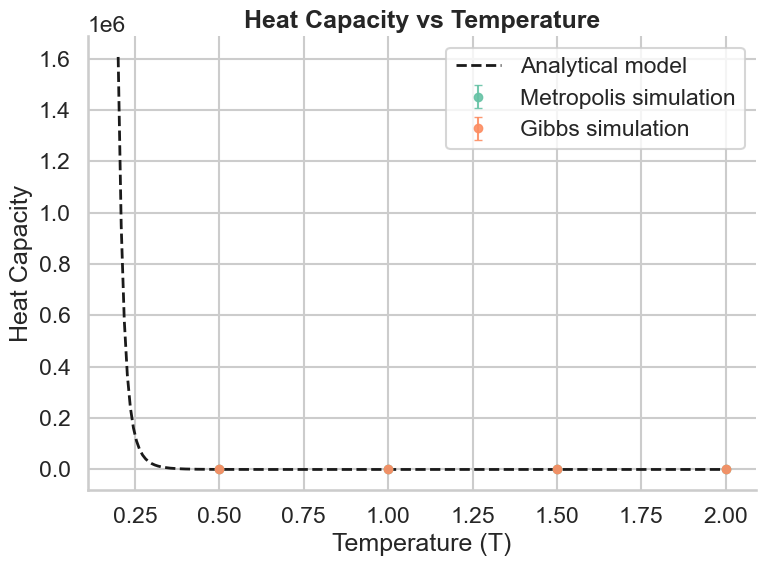


Plotting Magnetization across temperatures...


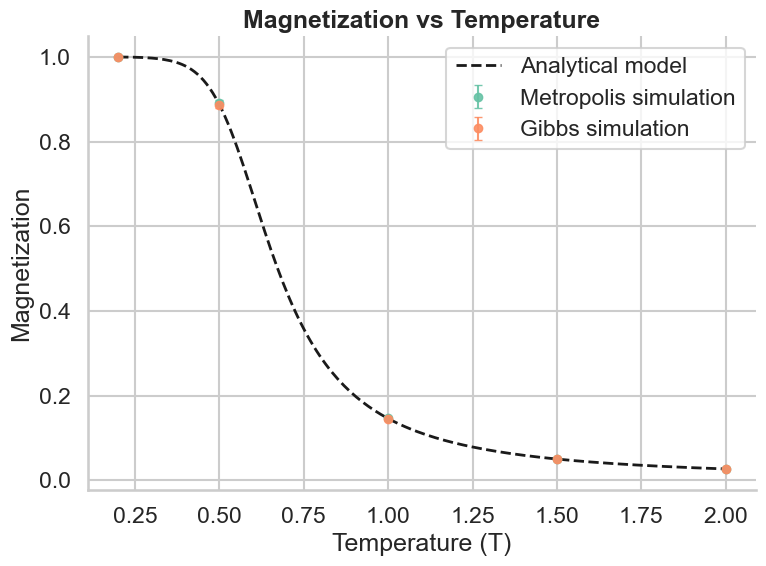


Plotting Magnetic Susceptibility across temperatures...


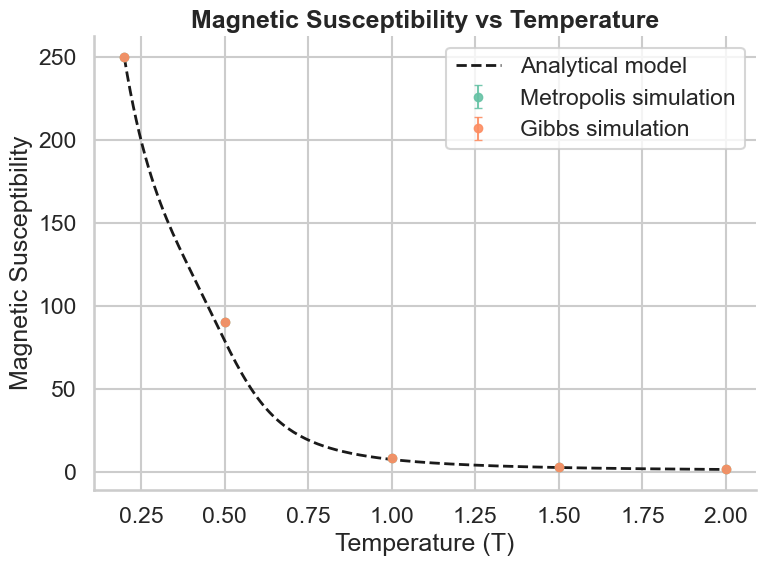

In [8]:
base_dir = "./ISING_1D/Output_data"
temps = [0.2, 0.5, 1.0, 1.5, 2.0]
algorithms = ["Metropolis", "Gibbs"]
plot_all_observables_vs_temp(base_dir, temps, algorithms, J=1.0, N=50)